In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("customer_big_dataset.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           1200 non-null   int64  
 1   Age                  1200 non-null   int64  
 2   AnnualIncome         1200 non-null   int64  
 3   SpendingScore        1200 non-null   int64  
 4   City                 1200 non-null   object 
 5   VisitFrequency       1200 non-null   int64  
 6   OnlinePurchaseRatio  1200 non-null   float64
 7   EducationLevel       1200 non-null   int64  
 8   FamilySize           1200 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 84.5+ KB


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop non-feature columns
features = df.drop(['CustomerID', 'Cluster'], axis=1, errors='ignore')

# Encode City if still categorical
features = pd.get_dummies(features, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


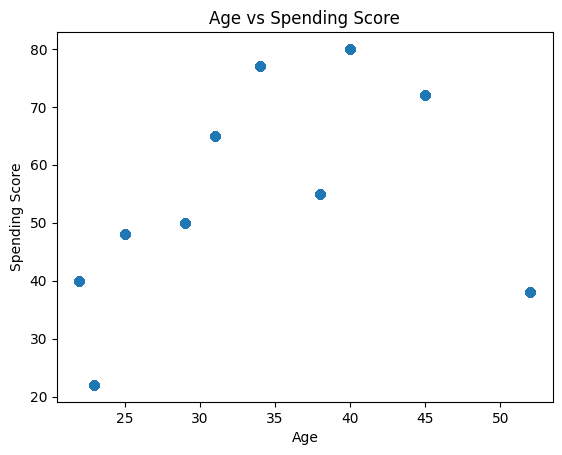

In [ ]:
plt.scatter(df["Age"], df["SpendingScore"])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()


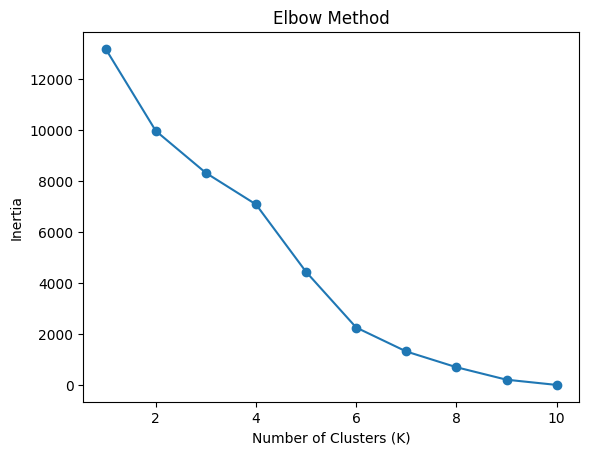

In [ ]:
from sklearn.cluster import KMeans

inertia_list = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

plt.plot(range(1, 11), inertia_list, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()


,CustomerID,Age,AnnualIncome,SpendingScore,City,VisitFrequency,OnlinePurchaseRatio,EducationLevel,FamilySize,Cluster
0,1,22,35000,40,CityA,12,0.3,2,4,1
1,2,25,42000,48,CityB,18,0.4,3,3,1
2,3,31,58000,65,CityC,10,0.6,4,5,3
3,4,45,86000,72,CityA,15,0.7,3,4,0
4,5,52,120000,38,CityD,7,0.2,5,2,4


In [ ]:
# Convert centers back to original scale
centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df_clean.columns
)

centers_original


ValueError: Shape of passed values is (5, 11), indices imply (5, 12)

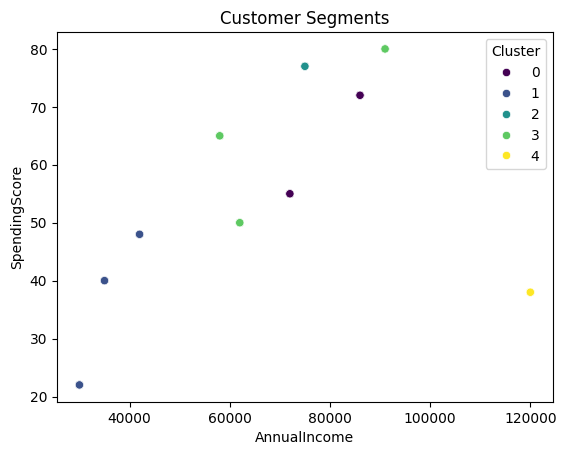

In [ ]:
sns.scatterplot(
    x="AnnualIncome",
    y="SpendingScore",
    hue="Cluster",
    data=df,
    palette="viridis"
)
plt.title("Customer Segments")
plt.show()


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]


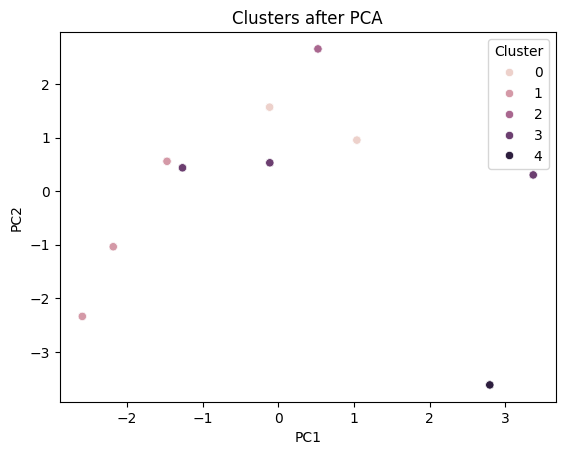

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df)
plt.title("Clusters after PCA")
plt.show()
